In [1]:
import gradio as gr
import pandas as pd
import os
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_tavily import TavilySearch
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.output_parsers import PydanticOutputParser
from langchain.schema.output_parser import OutputParserException
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from uuid import uuid4
from langgraph.graph import START, StateGraph, END
from typing_extensions import List, TypedDict
from langgraph.checkpoint.memory import MemorySaver

In [2]:
import getpass, warnings

warnings.filterwarnings('ignore')
load_dotenv(override=True)

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("GROQ API Key: ")

In [3]:
model_name_map = {
    "GPT-OSS-120B": "openai/gpt-oss-120b",
    "GPT-OSS-20B": "openai/gpt-oss-20b",
    "Qwen3.6-27B": "qwen/qwen3.6-27b"
}

model_choices = [
    "GPT-OSS-120B (Groq)",
    "GPT-OSS-20B (Groq)",
    "Qwen3.6-27B (Groq)"
]

In [4]:
def get_llm(model_choice, temperature):
    if "Groq" in model_choice:
        if "Qwen" in model_choice:

            return init_chat_model(model_name_map[model_choice.split(" ")[0]], model_provider="groq", temperature = temperature, reasoning_format="hidden")
        return init_chat_model(model_name_map[model_choice.split(" ")[0]], model_provider="groq", temperature = temperature)
    else:
        raise ValueError("Invalid model")

In [5]:
embeddings_model = OllamaEmbeddings(model="nomic-embed-text")

In [6]:
vector_store_chroma = Chroma(
    collection_name="mutual-funds",
    embedding_function=embeddings_model,
    persist_directory="./chroma_langchain_db",
)

In [7]:
loader = CSVLoader(file_path="mutual_funds_data.csv", source_column="scheme_code")
documents_raw = loader.load()

In [8]:
documents = []
for doc in documents_raw:
    try:
        row_data = dict(
            line.split(":", 1) for line in doc.page_content.split("\n") if ":" in line
        )
        row_data = {k.strip(): v.strip() for k, v in row_data.items()}

        page_text = f"""
        Scheme Name: {row_data.get('scheme_name', '')} |
        Fund House: {row_data.get('fund_house', '')} |
        Scheme Type: {row_data.get('scheme_type', '')} |
        Scheme Category: {row_data.get('scheme_category', '')} |
        Net Asset Value: {row_data.get('net_asset_value', row_data.get('nav', 0))} |
        Date: {row_data.get('date', '')}
        """

        metadata = {
            "Scheme Type": row_data.get("scheme_type", ""),
            "Scheme Category": row_data.get("scheme_category", "")
        }

        documents.append(Document(page_content=page_text, metadata=metadata))

    except Exception as e:
        print("Skipping row due to error:", e)

In [9]:
len(documents)

35559

In [10]:
print(documents[0].page_content)


        Scheme Name: Grindlays Super Saver Income Fund-GSSIF-Half Yearly Dividend |
        Fund House: Standard Chartered Mutual Fund |
        Scheme Type: Open Ended Schemes |
        Scheme Category: Income |
        Net Asset Value: 10.7205 |
        Date: 29-05-2008
        


In [11]:
len(documents)

35559

In [13]:
vector_store_chroma.add_documents(documents=documents[:5], ids=uuids[:5])

['c0637ed8-06e1-4c71-a7f0-0e9fce752ab9',
 'd1ee7db0-78e2-4306-825c-56582db2d5d7',
 'fe6e7573-63b2-41b3-99a5-c126a2792fdf',
 'f0ee5556-00f1-4b23-97f2-05aa441a8268',
 'fd4b99e7-4a82-4441-a230-5383f1d961d9']

In [14]:
retriever = vector_store_chroma.as_retriever()

In [15]:
class MutualFund(BaseModel):
    scheme_name: str = Field(description="Name of the mutual fund scheme")
    fund_house: str = Field(description="Fund house (AMC) that manages the scheme")
    scheme_type: str = Field(description="Type of the scheme, e.g. Open Ended Schemes")
    scheme_category: str = Field(description="Category of the scheme, e.g. Income, Growth, Liquid")

class MutualFundOutput(BaseModel):
    reasoning: str = Field(description="Natural language explanation of what is recommended and why")
    schemes: List[MutualFund] = Field(description="List of recommended mutual fund schemes")

parser = PydanticOutputParser(pydantic_object=MutualFundOutput)

In [16]:
template = ChatPromptTemplate.from_template("""You are a smart mutual fund advisor. Recommend a mutual fund investment portfolio based on the user's risk and return preferences.

User preferences:
{preferences}

You are given the following mutual funds for reference:
{context}

Rules:
1. Only recommend mutual fund schemes that are present in the reference list above. Do not make up any scheme.
2. Make sure no two selected mutual fund schemes fall under the same fund house AND scheme type.
3. Respect any constraint given by the user (for example, a specific fund house or category). If no scheme in the reference list matches, say so in the reasoning.
4. In the reasoning, explain what is recommended and why it matches the user's preferences.

{format_instructions}
""")

In [17]:
preference = "I want a low risk investment portfolio."
context_docs = retriever.invoke(preference)
relevant_text = "\n".join(doc.page_content for doc in context_docs)
llm = get_llm(model_choices[0], 0.7)
chain = template | llm | parser
input_dict = {"preferences": preference, "context": relevant_text, "format_instructions": parser.get_format_instructions()}
chain.invoke(input_dict).model_dump()

{'reasoning': 'Based on your preference for a low‑risk investment portfolio, I recommend two debt‑oriented open‑ended schemes that focus on short‑term and low‑duration instruments. Both funds aim to preserve capital and deliver modest, stable returns, making them suitable for conservative investors. The two selections come from different fund houses, satisfying the rule that no two recommended schemes share the same fund house and scheme type combination.',
 'schemes': [{'scheme_name': 'Sundaram Short Term Credit Risk Fund -Dividend',
   'fund_house': 'Sundaram Mutual Fund',
   'scheme_type': 'Open Ended Schemes',
   'scheme_category': 'Debt Scheme - Credit Risk Fund'},
  {'scheme_name': 'Franklin India Low Duration Fund - Quarterly - IDCW',
   'fund_house': 'Franklin Templeton Mutual Fund',
   'scheme_type': 'Open Ended Schemes',
   'scheme_category': 'Debt Scheme - Low Duration Fund'}]}

In [18]:
def generate_portfolio(model_choice, user_input):
    context_docs = retriever.invoke(user_input["preferences"])
    relevant_funds = "\n".join(doc.page_content for doc in context_docs)
    llm = get_llm(model_choice, user_input["temperature"])

    chain = template | llm
    output = chain.invoke({
        "preferences": user_input["preferences"],
        "context": relevant_funds,
        "format_instructions": parser.get_format_instructions()
    })

    try:
        result = parser.parse(output.content)
    except OutputParserException:
        return "Could not parse output.", None
    return result

In [19]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    result = generate_portfolio(model_choice, user_input)
    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []

    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [20]:
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [21]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [22]:
class State(TypedDict):
    preferences: str
    context: List[Document]
    answer: MutualFundOutput

In [23]:
def retrieve(state: State):
    relevant_funds = retriever.invoke(state["preferences"])
    return {"context": relevant_funds}

In [24]:
def generate(state: State):
    relevant_funds_str = "\n".join(doc.page_content for doc in state["context"])

    chain = template | llm_graph
    output = chain.invoke({
        "preferences": state["preferences"],
        "context": relevant_funds_str,
        "format_instructions": parser.get_format_instructions()
    })

    try:
        result = parser.parse(output.content)
    except OutputParserException:

        return {"answer": ("Could not parse output.", None)}

    return {"answer": result}

In [25]:
graph_builder = StateGraph(State)

graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

In [26]:
graph = graph_builder.compile()

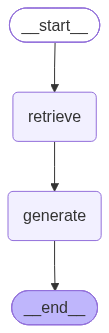

In [27]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
preferences = "I want a low risk investment portfolio."
llm_graph = get_llm(model_choices[0], 0.7)
result = graph.invoke({"preferences": preferences})
print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: [Document(id='d235a731-7568-45a6-a741-6a3338f4cf43', metadata={'Scheme Category': 'Debt Scheme - Credit Risk Fund', 'Scheme Type': 'Open Ended Schemes'}, page_content='\n        Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend | \n        Fund House: Sundaram Mutual Fund | \n        Scheme Type: Open Ended Schemes | \n        Scheme Category: Debt Scheme - Credit Risk Fund | \n        Net Asset Value: 11.3002 | \n        Date: 29-12-2020\n        '), Document(id='e73da1a4-eb91-439e-b59a-3919ea441489', metadata={'Scheme Type': 'Open Ended Schemes', 'Scheme Category': 'Debt Scheme - Credit Risk Fund'}, page_content='\n        Scheme Name: Sundaram Short Term Credit Risk Fund -Dividend | \n        Fund House: Sundaram Mutual Fund | \n        Scheme Type: Open Ended Schemes | \n        Scheme Category: Debt Scheme - Credit Risk Fund | \n        Net Asset Value: 11.3002 | \n        Date: 29-12-2020\n        '), Document(id='3eda705d-1c4d-4daf-baee-f515d3be98e3', metadata

In [29]:
def gradio_interface(preferences, model_choice, temperature):
    user_input = {
        "preferences": preferences,
        "model_choice": model_choice,
        "temperature": temperature,
    }
    global llm_graph
    llm_graph = get_llm(user_input["model_choice"], user_input["temperature"])
    result = graph.invoke({"preferences": preferences})["answer"]

    if not result or isinstance(result, str):
        return result, []
    if isinstance(result, tuple):
        explanation, _ = result
        return explanation, []

    list_output = "\n".join(
        f"🔹 {scheme.scheme_name} | Fund House: {scheme.fund_house}"
        for scheme in result.schemes
    )

    return result.reasoning, list_output

In [30]:
with gr.Blocks(title="Smart Mutual Fund Advisor") as demo:
    gr.Markdown("## Smart Mutual Fund Advisor")
    gr.Markdown("Enter your investment preferences and let AI suggest a portfolio!")

    with gr.Row():
        preferences_input = gr.Textbox(
            label="Describe your investment needs",
            placeholder="e.g., high return portfolio, only from Aditya Birla fund house",
            lines=2
        )

    with gr.Accordion("LLM Settings (Advanced)", open=False):
        model_dropdown = gr.Dropdown(
            label="Model",
            choices=model_choices,
            value=model_choices[0]
        )
        temperature_slider = gr.Slider(
            minimum=0.0, maximum=2, value=0.7, step=0.1,
            label="Temperature"
        )

    run_button = gr.Button("Generate Portfolio")

    with gr.Row():
        reasoning_output = gr.Textbox(label="Remarks", lines=2)

    with gr.Row():
        fund_list_output = gr.Textbox(label="Recommended Mutual Funds", lines=10)

    run_button.click(
        fn=gradio_interface,
        inputs=[preferences_input, model_dropdown, temperature_slider],
        outputs=[reasoning_output, fund_list_output]
    )

In [31]:
demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
